# KNN Classification From Scratch
Goal:
- Build KNN without sklearn
- and understand what happens internally

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# simple dataset

X = np.array([
    [1,1],
    [2,2],
    [3,3],
    [7,7],
    [8,8],
    [9,9]
])

y = np.array([0,0,0,1,1,1])

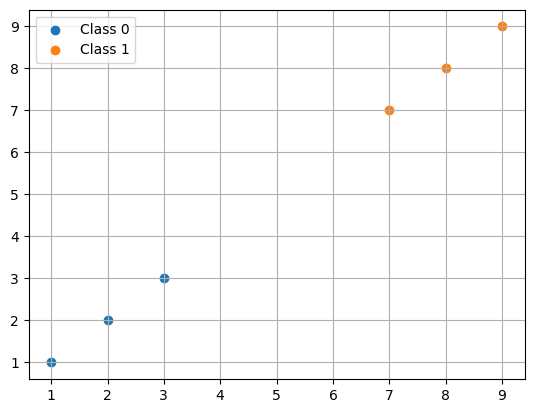

In [3]:
# visualize data

plt.scatter(X[y==0][:,0], X[y==0][:,1], label="Class 0")
plt.scatter(X[y==1][:,0], X[y==1][:,1], label="Class 1")

plt.legend()
plt.grid()

plt.show()

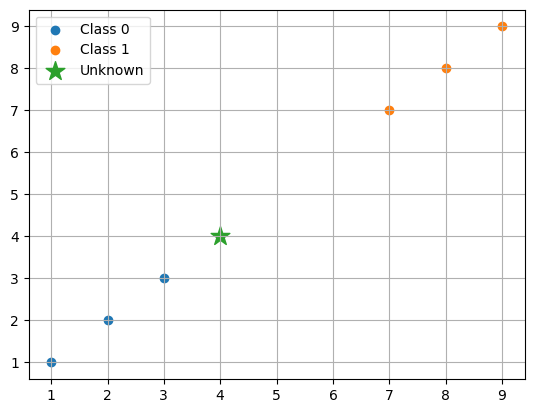

In [4]:
# point we want to classify

new_point = np.array([4,4])

plt.scatter(X[y==0][:,0], X[y==0][:,1], label="Class 0")
plt.scatter(X[y==1][:,0], X[y==1][:,1], label="Class 1")

plt.scatter(new_point[0], new_point[1], marker="*", s=200, label="Unknown")

plt.legend()
plt.grid()

plt.show()

We now need to find which points are closest to the new point.

In [6]:
# euclidean distance

def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1-p2)**2))

In [7]:
# distance from new point to all points

distances = []

for point in X:
    d = euclidean_distance(point, new_point)
    distances.append(d)

distances

[np.float64(4.242640687119285),
 np.float64(2.8284271247461903),
 np.float64(1.4142135623730951),
 np.float64(4.242640687119285),
 np.float64(5.656854249492381),
 np.float64(7.0710678118654755)]

In [8]:
# combine points and distances

for point, dist in zip(X, distances):
    print(point, "->", round(dist,2))

[1 1] -> 4.24
[2 2] -> 2.83
[3 3] -> 1.41
[7 7] -> 4.24
[8 8] -> 5.66
[9 9] -> 7.07


In [9]:
# sort distances

sorted_indices = np.argsort(distances)

sorted_indices

array([2, 1, 0, 3, 4, 5])

In [10]:
# nearest 3 neighbors

k = 3

nearest_indices = sorted_indices[:k]

nearest_indices

array([2, 1, 0])

In [11]:
# classes of nearest neighbors

nearest_labels = y[nearest_indices]

nearest_labels

array([0, 0, 0])

In [12]:
# majority voting

prediction = np.bincount(nearest_labels).argmax()

print("Predicted Class :", prediction)

Predicted Class : 0


KNN predicts the class that appears most frequently among the nearest neighbors.

**Now Building Actual Function**

In [13]:
def knn_predict(X, y, new_point, k=3):

    distances = []

    for point in X:
        d = np.sqrt(np.sum((point-new_point)**2))
        distances.append(d)

    nearest = np.argsort(distances)[:k]

    labels = y[nearest]

    prediction = np.bincount(labels).argmax()

    return prediction

In [14]:
pred = knn_predict(X, y, np.array([8.5,8]), k=3)

print(pred)

1


In [15]:
pred = knn_predict(X, y, np.array([8.5,8]), k=3)

print(pred)

1


In [16]:
pred = knn_predict(X, y, np.array([2,1]), k=3)

print(pred)

0


# Conclusion

- KNN is a supervised learning algorithm.
- It is a distance-based algorithm.
- No actual training happens in KNN.
- The entire dataset is stored in memory.
- Predictions are made using the nearest neighbors.
- Euclidean Distance is the most commonly used distance metric.
- The value of K affects model performance.
- Small K can lead to overfitting.
- Large K can lead to underfitting.
- Similar data points are expected to belong to the same class.

KNN follows a simple approach:

Calculate Distance → Find K Nearest Neighbors → Majority Voting → Prediction